# Step 1: Import Libraries & Load Data

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv(r'D:\ABHI-VSCODE\19.CAPSTONE-PROJECT DEPLOYMENT\Customer Churn & Retention Analysis\Churn_Modelling.csv')
df

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [8]:
print(df.head())
print(df.info())

   RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1    15634602  Hargrave          619    France  Female   42   
1          2    15647311      Hill          608     Spain  Female   41   
2          3    15619304      Onio          502    France  Female   42   
3          4    15701354      Boni          699    France  Female   39   
4          5    15737888  Mitchell          850     Spain  Female   43   

   Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  \
0       2       0.00              1          1               1   
1       1   83807.86              1          0               1   
2       8  159660.80              3          1               0   
3       1       0.00              2          0               0   
4       2  125510.82              1          1               1   

   EstimatedSalary  Exited  
0        101348.88       1  
1        112542.58       0  
2        113931.57       1  
3         93826.63       0  
4         790

In [9]:
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

# Step 2: Data Cleaning & Preprocessing

In [10]:
# Drop irrelevant columns (like RowNumber, CustomerId, Surname if present)
df = df.drop(columns=["RowNumber", "CustomerId", "Surname"], errors="ignore")

In [11]:
# Encode categorical variables
df = pd.get_dummies(df, columns=["Geography", "Gender"], drop_first=True)

In [12]:
# Check for missing values
print(df.isnull().sum())

CreditScore          0
Age                  0
Tenure               0
Balance              0
NumOfProducts        0
HasCrCard            0
IsActiveMember       0
EstimatedSalary      0
Exited               0
Geography_Germany    0
Geography_Spain      0
Gender_Male          0
dtype: int64


#  Step 3: Exploratory Data Analysis (EDA)
       --Churn Distribution

C:\Users\abhis\AppData\Local\Temp\ipykernel_14016\2402403779.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Exited", data=df, palette="Set2")


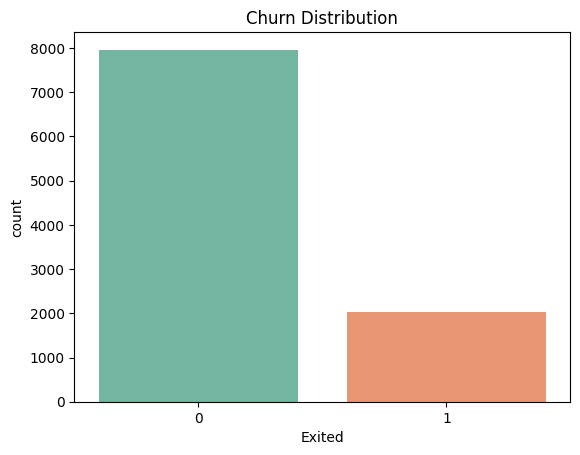

In [15]:
sns.countplot(x="Exited", data=df, palette="Set2")
plt.title("Churn Distribution")
plt.show()


        ---Churn by Geography       

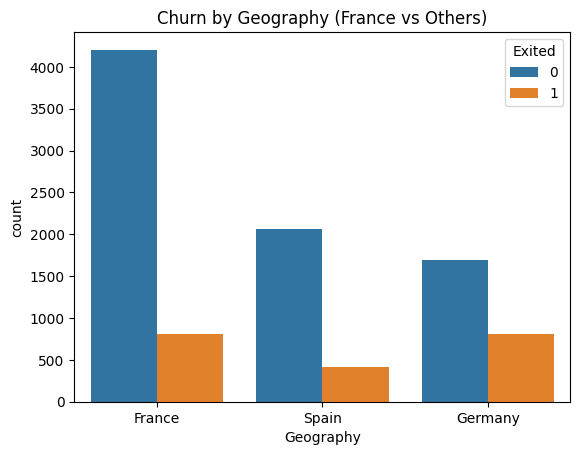

In [17]:
df['Geography'] = 'France'
df.loc[df['Geography_Germany'], 'Geography'] = 'Germany'
df.loc[df['Geography_Spain'], 'Geography'] = 'Spain'
sns.countplot(x="Geography", hue="Exited", data=df)
plt.title("Churn by Geography (France vs Others)")
plt.show()


     --Age vs Chain

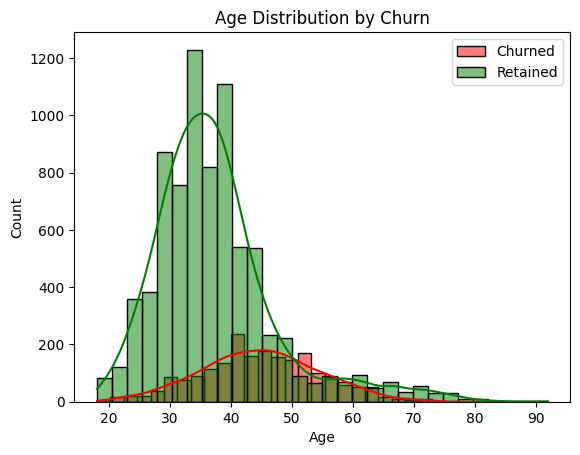

In [18]:
sns.histplot(df[df["Exited"]==1]["Age"], bins=30, color="red", label="Churned", kde=True)
sns.histplot(df[df["Exited"]==0]["Age"], bins=30, color="green", label="Retained", kde=True)
plt.legend()
plt.title("Age Distribution by Churn")
plt.show()


    --Coorelation Heatmap    

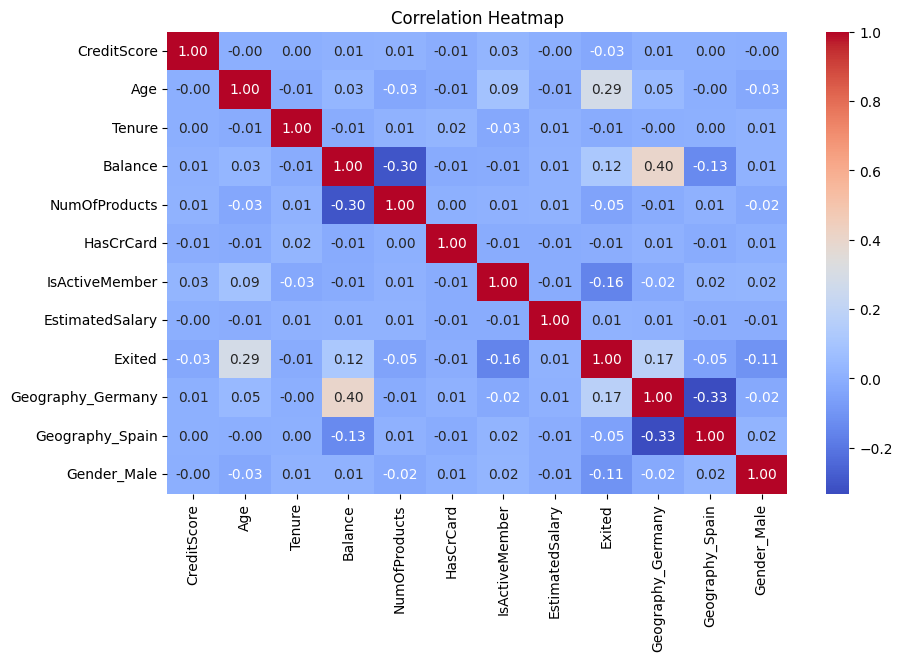

In [20]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()


# Step 4: Churn Driver Insights

In [21]:
# Group by Active Member
active_churn = df.groupby("IsActiveMember")["Exited"].mean()
print("Churn Rate by Active Member:\n", active_churn)

# Group by Number of Products
product_churn = df.groupby("NumOfProducts")["Exited"].mean()
print("Churn Rate by Number of Products:\n", product_churn)


Churn Rate by Active Member:
 IsActiveMember
0    0.268509
1    0.142691
Name: Exited, dtype: float64
Churn Rate by Number of Products:
 NumOfProducts
1    0.277144
2    0.075817
3    0.827068
4    1.000000
Name: Exited, dtype: float64


# Step 5: Retention Strategy Visualization

C:\Users\abhis\AppData\Local\Temp\ipykernel_14016\3642004232.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="NumOfProducts", y="Exited", data=df, palette="Blues")


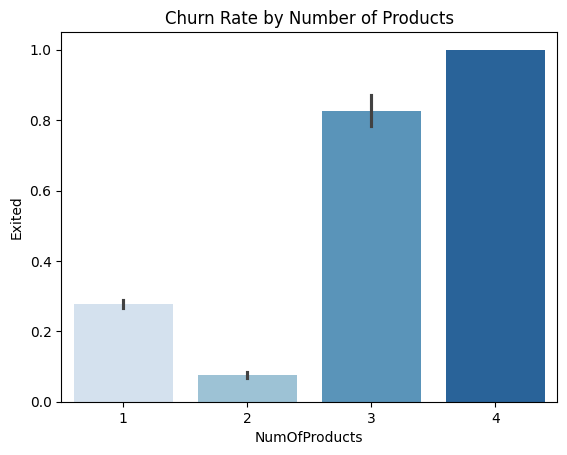

C:\Users\abhis\AppData\Local\Temp\ipykernel_14016\3642004232.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="IsActiveMember", y="Exited", data=df, palette="Oranges")


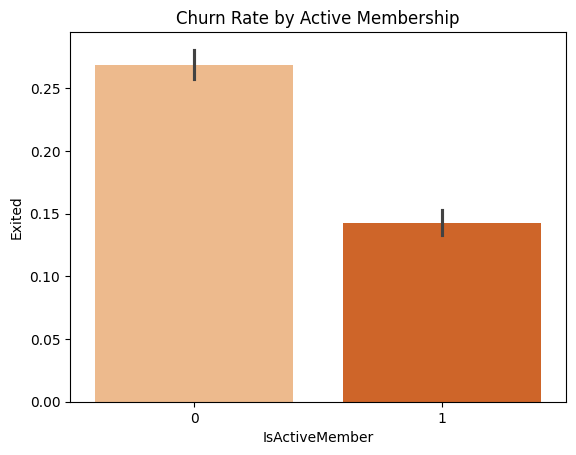

In [22]:
sns.barplot(x="NumOfProducts", y="Exited", data=df, palette="Blues")
plt.title("Churn Rate by Number of Products")
plt.show()

sns.barplot(x="IsActiveMember", y="Exited", data=df, palette="Oranges")
plt.title("Churn Rate by Active Membership")
plt.show()


# Step 6 (Optional): Predictive Modeling

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# Features & Target
X = df.drop("Exited", axis=1)
y = df["Exited"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train.drop("Geography", axis=1))
X_test = scaler.transform(X_test.drop("Geography", axis=1))

# Logistic Regression
model = LogisticRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


[[1543   64]
 [ 314   79]]
              precision    recall  f1-score   support

           0       0.83      0.96      0.89      1607
           1       0.55      0.20      0.29       393

    accuracy                           0.81      2000
   macro avg       0.69      0.58      0.59      2000
weighted avg       0.78      0.81      0.77      2000

